In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import os

drive_path = "/content/drive/MyDrive/Assignment Information Security"

print("Files/Folders in My Drive:")
print(os.listdir(drive_path))

Files/Folders in My Drive:
['UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv']


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [49]:
train_path = "/content/drive/MyDrive/Assignment Information Security/UNSW_NB15_training-set.csv"
test_path = "/content/drive/MyDrive/Assignment Information Security/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

Training dataset shape: (175341, 45)
Testing dataset shape: (82332, 45)


In [50]:
print("Training Dataset:")
display(train_df.head())

print("\nTesting Dataset:")
display(test_df.head())

Training Dataset:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0



Testing Dataset:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [51]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

In [52]:
missing_values = train_df.isnull().sum()

print("Missing values in training dataset:")
display(missing_values[missing_values > 0])

Missing values in training dataset:


,0


In [53]:
missing_test = test_df.isnull().sum()

print("Missing values in testing dataset:")
display(missing_test[missing_test > 0])

Missing values in testing dataset:


,0


In [54]:
# Display basic statistical information for numerical features
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,175341.0,8.767100e+04,5.061673e+04,1.0,43836.000000,87671.000000,1.315060e+05,1.753410e+05
dur,175341.0,1.359389e+00,6.480249e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540619e+04,1.654010e+05,0.0,32.786140,3225.806520,1.250000e+05,1.000000e+06
sttl,175341.0,1.795470e+02,1.029400e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,175341.0,7.960957e+01,1.105069e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.338870,879674.750000,8.888889e+07,5.988000e+09


Normal vs Malicious Traffic Distribution

The `label` column is the target variable:

- 0 = Normal traffic
- 1 = Malicious/Attack traffic

In [55]:
label_counts = train_df["label"].value_counts().sort_index()

print("Traffic Class Distribution:")
print(label_counts)

print("\nClass Percentages:")
print((train_df["label"].value_counts(normalize=True) * 100).sort_index())

Traffic Class Distribution:
label
0     56000
1    119341
Name: count, dtype: int64

Class Percentages:
label
0    31.937767
1    68.062233
Name: proportion, dtype: float64


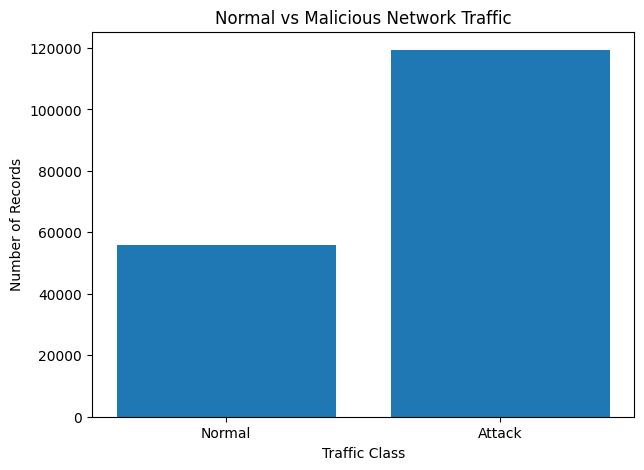

In [56]:
#Target Distribution Graph
plt.figure(figsize=(7, 5))

labels = ["Normal", "Attack"]
counts = [
    train_df["label"].value_counts().get(0, 0),
    train_df["label"].value_counts().get(1, 0)
]

plt.bar(labels, counts)

plt.title("Normal vs Malicious Network Traffic")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.show()

### Attack Category Distribution

The UNSW-NB15 dataset contains multiple categories of malicious
network activity. The `attack_cat` feature is examined to understand
the types of attacks represented in the dataset.

In [57]:
attack_distribution = train_df["attack_cat"].value_counts()

print("Attack Category Distribution:")
display(attack_distribution)

Attack Category Distribution:


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133


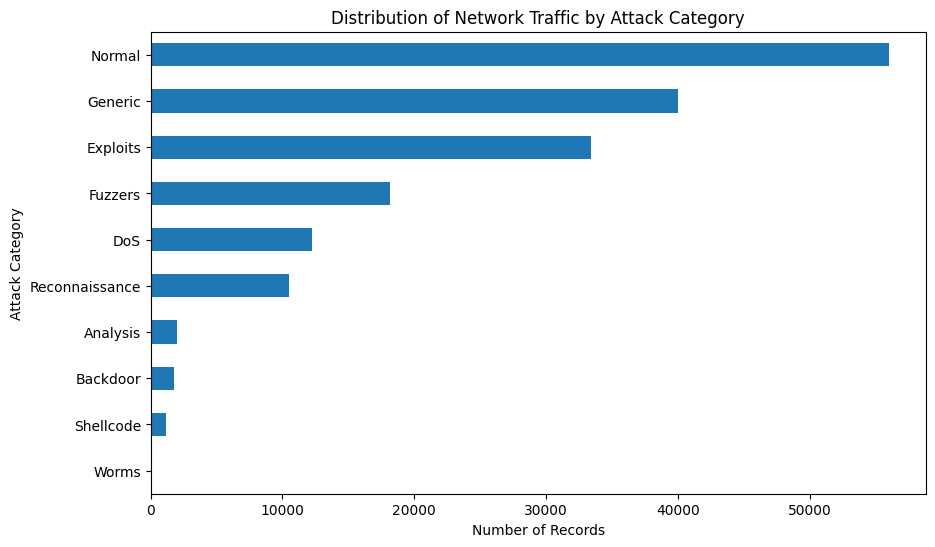

In [58]:
#Attack Categories graph
plt.figure(figsize=(10, 6))

attack_distribution.sort_values().plot(kind="barh")

plt.title("Distribution of Network Traffic by Attack Category")
plt.xlabel("Number of Records")
plt.ylabel("Attack Category")
plt.show()

### Categorical Feature Analysis

The dataset contains categorical network features such as protocol,
service, and connection state. These features must be converted into
a numerical representation.

In [59]:
categorical_columns = train_df.select_dtypes(include=["object"]).columns

print("Categorical Features:")
print(list(categorical_columns))

for column in categorical_columns:
    print(f"\n{column}:")
    print("Unique values:", train_df[column].nunique())
    print(train_df[column].value_counts().head(10))

Categorical Features:
['proto', 'service', 'state', 'attack_cat']

proto:
Unique values: 133
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
ipv6        201
mobile      201
Name: count, dtype: int64

service:
Unique values: 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
Name: count, dtype: int64

state:
Unique values: 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

attack_cat:
Unique values: 10
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtyp

In [60]:
print("Training columns:", len(train_df.columns))
print("Testing columns:", len(test_df.columns))


Training columns: 45
Testing columns: 45


In [61]:
print("Training labels:")
print(train_df["label"].unique())

print("\nTesting labels:")
print(test_df["label"].unique())

Training labels:
[0 1]

Testing labels:
[0 1]


## Data Preprocessing

The binary `label` column is used as the prediction target, where 0
represents normal traffic and 1 represents malicious traffic.

The `attack_cat` column is excluded from the model features because it
directly describes the attack category and could introduce target
information leakage.

The `id` column is also removed because it is an identifier rather than
a meaningful network traffic feature.

In [62]:
# Create copies to keep the original datasets unchanged
train_processed = train_df.copy()
test_processed = test_df.copy()

# Separate target variable
y_train = train_processed["label"]
y_test = test_processed["label"]

# Remove target, attack category and identifier
X_train = train_processed.drop(columns=["label", "attack_cat", "id"])
X_test = test_processed.drop(columns=["label", "attack_cat", "id"])

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Target shape:", y_train.shape)

Training features shape: (175341, 42)
Testing features shape: (82332, 42)
Target shape: (175341,)


In [63]:
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumber of numerical features:", len(numerical_features))

Categorical features:
['proto', 'service', 'state']

Number of categorical features: 3

Number of numerical features: 39


In [64]:
#Categorical → One-Hot Encoding
#Numerical → Standardization

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [65]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (175341, 194)
Processed testing shape: (82332, 194)


## Machine Learning Model Development

A Random Forest classifier is selected as the primary machine learning
algorithm for the intrusion detection solution.

Random Forest is suitable for network traffic classification because it
can model complex relationships between multiple network traffic
features and provides a robust classification approach.

In [66]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training class distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Training class percentages:
label
1    68.06
0    31.94
Name: proportion, dtype: float64


In [67]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")

rf_model.fit(X_train_processed, y_train)

print("Random Forest training completed successfully.")

Training Random Forest model...
Random Forest training completed successfully.


In [68]:
print("Generating predictions on unseen test data...")

y_pred = rf_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Generating predictions on unseen test data...
Predictions generated successfully.
Number of predictions: 82332


In [69]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.8711
Accuracy: 87.11%


In [70]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Precision: {precision * 100:.2f}%")

print(f"\nRecall: {recall:.4f}")
print(f"Recall: {recall * 100:.2f}%")

Precision: 0.8178
Precision: 81.78%

Recall: 0.9854
Recall: 98.54%


In [71]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"]
    )
)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.73      0.84     37000
      Attack       0.82      0.99      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.90      0.86      0.86     82332
weighted avg       0.89      0.87      0.87     82332



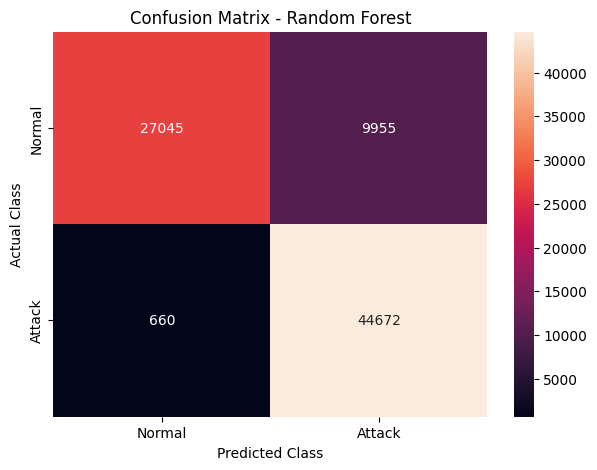

In [72]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## Feature Importance Analysis

Random Forest provides feature importance scores that help identify
which network traffic characteristics contribute most to the
classification of normal and malicious traffic.

This analysis improves the interpretability of the intrusion detection
solution and helps identify potentially important indicators of
malicious network activity.

In [73]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
display(feature_importance.head(20))

,Feature,Importance
6,num__sttl,0.108622
28,num__ct_state_ttl,0.076468
9,num__dload,0.052708
5,num__rate,0.049906
7,num__dttl,0.046082
8,num__sload,0.043948
21,num__synack,0.039141
20,num__tcprtt,0.034782
3,num__sbytes,0.031721
37,num__ct_srv_dst,0.029986


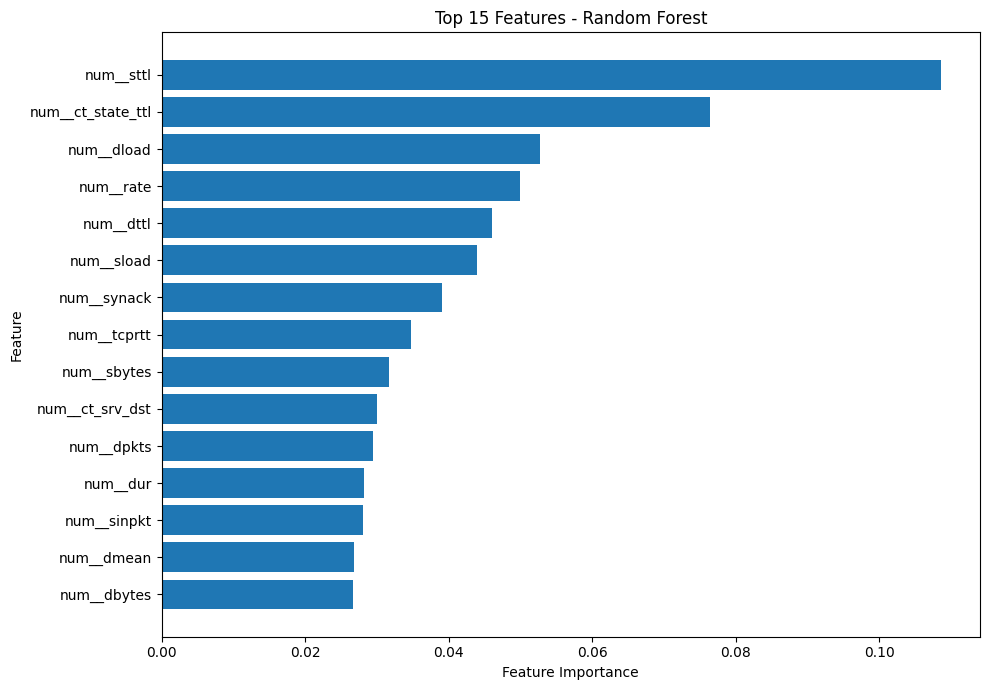

In [74]:
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [75]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

True Negatives (TN): 27045
False Positives (FP): 9955
False Negatives (FN): 660
True Positives (TP): 44672


## Attack Category Detection Analysis

The UNSW-NB15 dataset contains multiple categories of malicious
network activity. Although the model performs binary classification
(normal vs attack), the original attack categories are used after
prediction to analyze how effectively the model detects different
types of attacks.

The attack category is not provided as an input feature to the model.
It is used only for post-prediction security analysis.

In [76]:
# Create a copy of the original test data for analysis
attack_analysis = test_df[["attack_cat", "label"]].copy()

# Add model predictions
attack_analysis["prediction"] = y_pred

# Calculate detection rate for each category
category_results = []

for category in attack_analysis["attack_cat"].unique():

    category_data = attack_analysis[
        attack_analysis["attack_cat"] == category
    ]

    total = len(category_data)

    if category == "Normal":
        correct = (category_data["prediction"] == 0).sum()
    else:
        correct = (category_data["prediction"] == 1).sum()

    detection_rate = (correct / total) * 100

    category_results.append({
        "Attack Category": category,
        "Total Samples": total,
        "Correctly Classified": correct,
        "Detection Rate (%)": detection_rate
    })

category_results_df = pd.DataFrame(category_results)

category_results_df = category_results_df.sort_values(
    by="Detection Rate (%)",
    ascending=False
)

display(category_results_df)

,Attack Category,Total Samples,Correctly Classified,Detection Rate (%)
7,Worms,44,44,100.000000
2,Backdoor,583,583,100.000000
9,Generic,18871,18871,100.000000
1,Reconnaissance,3496,3494,99.942792
3,DoS,4089,4086,99.926632
5,Analysis,677,676,99.852290
4,Exploits,11132,11087,99.595760
8,Shellcode,378,375,99.206349
6,Fuzzers,6062,5456,90.003299
0,Normal,37000,27045,73.094595


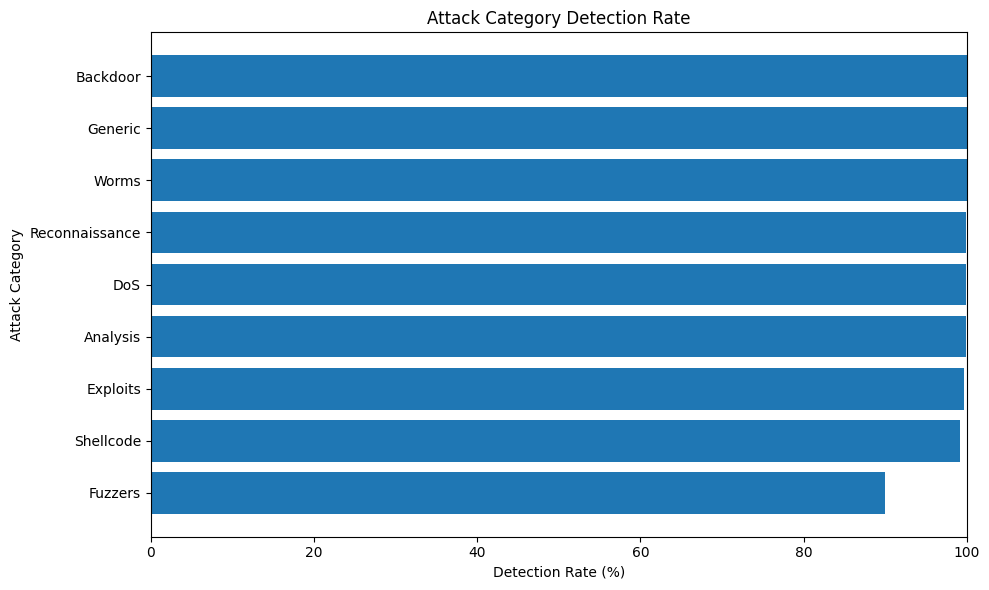

In [77]:
attack_categories = category_results_df[
    category_results_df["Attack Category"] != "Normal"
].sort_values(
    by="Detection Rate (%)",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    attack_categories["Attack Category"],
    attack_categories["Detection Rate (%)"]
)

plt.title("Attack Category Detection Rate")
plt.xlabel("Detection Rate (%)")
plt.ylabel("Attack Category")

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [78]:
results_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Attack Recall",
        "False Positives",
        "False Negatives"
    ],
    "Value": [
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        fp,
        fn
    ]
})

display(results_summary)

,Metric,Value
0,Accuracy,87.11%
1,Precision,81.78%
2,Attack Recall,98.54%
3,False Positives,9955
4,False Negatives,660


In [79]:
# Real-Time Threat Detection Simulation

def detect_network_traffic(traffic_record):
    """
    Simulates real-time detection of a single network traffic record.
    """

    # Convert incoming record into DataFrame
    incoming_data = pd.DataFrame([traffic_record])

    # Remove fields that were not used by the model
    incoming_data = incoming_data.drop(
        columns=["label", "attack_cat", "id"],
        errors="ignore"
    )

    # Apply the same preprocessing used during training
    processed_data = preprocessor.transform(incoming_data)

    # Make prediction
    prediction = rf_model.predict(processed_data)[0]

    # Get probability
    probabilities = rf_model.predict_proba(processed_data)[0]

    # Identify probability of malicious class (1)
    attack_probability = probabilities[
        list(rf_model.classes_).index(1)
    ]

    # Detection result
    if prediction == 1:
        status = "MALICIOUS TRAFFIC"
    else:
        status = "NORMAL TRAFFIC"

    print("=" * 50)
    print("REAL-TIME INTRUSION DETECTION")
    print("=" * 50)
    print(f"Prediction       : {prediction}")
    print(f"Threat Status    : {status}")
    print(f"Attack Probability: {attack_probability * 100:.2f}%")
    print("=" * 50)

    return prediction, attack_probability

In [80]:
# Find one normal traffic record
normal_sample = test_df[test_df["label"] == 0].iloc[0]

# Find one malicious traffic record
attack_sample = test_df[test_df["label"] == 1].iloc[0]

print("NORMAL TRAFFIC SAMPLE")
detect_network_traffic(normal_sample)

print("\nMALICIOUS TRAFFIC SAMPLE")
detect_network_traffic(attack_sample)

NORMAL TRAFFIC SAMPLE
REAL-TIME INTRUSION DETECTION
Prediction       : 1
Threat Status    : MALICIOUS TRAFFIC
Attack Probability: 78.49%

MALICIOUS TRAFFIC SAMPLE
REAL-TIME INTRUSION DETECTION
Prediction       : 1
Threat Status    : MALICIOUS TRAFFIC
Attack Probability: 100.00%


(np.int64(1), np.float64(1.0))